# CT107-3-3 Text Analytics and Sentiment Analysis
## Part A — Q3: POS Taggers & Syntactic Analysis (Parse Trees)
**Dataset:** `Data_2.txt`

### Setup — Import Libraries and Load Data

In [1]:
import re
import nltk
from nltk.tokenize import word_tokenize
from textblob import TextBlob

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

DATA_PATH = r"D:\TXSA\Part A Dataset\Part A Dataset\Data_2.txt"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = f.read().strip()

text = re.sub(r'^\d+\t', '', raw, flags=re.MULTILINE).strip()
# Remove trailing period for parsing
text_clean = text.rstrip('.')

print("Sentence:")
print(text)

tokens = word_tokenize(text)
print(f"\nTokens: {tokens}")

Sentence:
The big black dog barked at the white cat and chased away.

Tokens: ['The', 'big', 'black', 'dog', 'barked', 'at', 'the', 'white', 'cat', 'and', 'chased', 'away', '.']


---
## Q3(a) — POS Tagging: NLTK, TextBlob, and Regex Tagger
*(3 marks)*

In [2]:
# ── Method 1: NLTK Averaged Perceptron Tagger ──────────────────────────────
nltk_tags = nltk.pos_tag(tokens)

print("[Method 1] NLTK pos_tag (Averaged Perceptron Tagger):")
print(nltk_tags)
print()
print(f"{'Token':<15} {'POS Tag':<10} Meaning")
print("-" * 50)
tag_meanings = {
    'DT': 'Determiner', 'JJ': 'Adjective', 'NN': 'Noun (singular)',
    'NNS': 'Noun (plural)', 'VBD': 'Verb (past tense)', 'IN': 'Preposition',
    'CC': 'Coordinating conjunction', 'RB': 'Adverb', '.' : 'Punctuation'
}
for word, tag in nltk_tags:
    print(f"{word:<15} {tag:<10} {tag_meanings.get(tag, tag)}")

[Method 1] NLTK pos_tag (Averaged Perceptron Tagger):
[('The', 'DT'), ('big', 'JJ'), ('black', 'JJ'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'JJ'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'RB'), ('.', '.')]

Token           POS Tag    Meaning
--------------------------------------------------
The             DT         Determiner
big             JJ         Adjective
black           JJ         Adjective
dog             NN         Noun (singular)
barked          VBD        Verb (past tense)
at              IN         Preposition
the             DT         Determiner
white           JJ         Adjective
cat             NN         Noun (singular)
and             CC         Coordinating conjunction
chased          VBD        Verb (past tense)
away            RB         Adverb
.               .          Punctuation


In [3]:
# ── Method 2: TextBlob POS Tagger ──────────────────────────────────────────
blob = TextBlob(text)
textblob_tags = blob.tags

print("[Method 2] TextBlob POS Tagger:")
print(textblob_tags)
print()
print(f"{'Token':<15} {'POS Tag':<10} Meaning")
print("-" * 50)
for word, tag in textblob_tags:
    print(f"{word:<15} {tag:<10} {tag_meanings.get(tag, tag)}")

[Method 2] TextBlob POS Tagger:
[('The', 'DT'), ('big', 'JJ'), ('black', 'JJ'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'JJ'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'RB')]

Token           POS Tag    Meaning
--------------------------------------------------
The             DT         Determiner
big             JJ         Adjective
black           JJ         Adjective
dog             NN         Noun (singular)
barked          VBD        Verb (past tense)
at              IN         Preposition
the             DT         Determiner
white           JJ         Adjective
cat             NN         Noun (singular)
and             CC         Coordinating conjunction
chased          VBD        Verb (past tense)
away            RB         Adverb


In [4]:
# ── Method 3: Regular Expression Tagger ────────────────────────────────────
# Assigns POS based on word-form heuristics (suffix rules + closed-class lists)
regex_patterns = [
    (r'^-?[0-9]+(\.[0-9]+)?$',            'CD'),   # cardinal digits
    (r'.*ing$',                             'VBG'),  # present participle
    (r'.*ed$',                              'VBD'),  # past tense verb
    (r'.*es$',                              'VBZ'),  # 3rd-person singular present
    (r'.*\'s$',                            'NN$'),  # possessive noun
    (r'.*s$',                               'NNS'),  # plural noun
    (r'^(The|the|A|a|An|an)$',             'DT'),   # determiners
    (r'^(and|or|but|nor)$',                'CC'),   # coordinating conjunctions
    (r'^(at|in|on|by|to|of|from|with)$',  'IN'),   # prepositions
    (r'^(away|very|quite|just)$',          'RB'),   # common adverbs
    (r'.*',                                 'NN'),   # default: noun
]
regex_tagger = nltk.RegexpTagger(regex_patterns)
regex_tags   = regex_tagger.tag(tokens)

print("[Method 3] Regular Expression Tagger:")
print(regex_tags)
print()
print(f"{'Token':<15} {'POS Tag':<10} Meaning")
print("-" * 50)
for word, tag in regex_tags:
    print(f"{word:<15} {tag:<10} {tag_meanings.get(tag, tag)}")

[Method 3] Regular Expression Tagger:
[('The', 'DT'), ('big', 'NN'), ('black', 'NN'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'NN'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'RB'), ('.', 'NN')]

Token           POS Tag    Meaning
--------------------------------------------------
The             DT         Determiner
big             NN         Noun (singular)
black           NN         Noun (singular)
dog             NN         Noun (singular)
barked          VBD        Verb (past tense)
at              IN         Preposition
the             DT         Determiner
white           NN         Noun (singular)
cat             NN         Noun (singular)
and             CC         Coordinating conjunction
chased          VBD        Verb (past tense)
away            RB         Adverb
.               NN         Noun (singular)


---
## Q3(b) — Comparison of POS Taggers
*(3 marks)*

In [5]:
# Side-by-side comparison table
tb_dict    = {word: tag for word, tag in textblob_tags}
regex_dict = {word: tag for word, tag in regex_tags}

print(f"{'Token':<12} {'NLTK':<10} {'TextBlob':<12} {'Regex':<10} {'Match?'}")
print("-" * 60)
for word, ntag in nltk_tags:
    tbtag = tb_dict.get(word, 'N/A')
    rtag  = regex_dict.get(word, 'N/A')
    match = "✓" if ntag == tbtag == rtag else ("≈" if ntag == tbtag else "✗")
    print(f"{word:<12} {ntag:<10} {tbtag:<12} {rtag:<10} {match}")

Token        NLTK       TextBlob     Regex      Match?
------------------------------------------------------------
The          DT         DT           DT         ✓
big          JJ         JJ           NN         ≈
black        JJ         JJ           NN         ≈
dog          NN         NN           NN         ✓
barked       VBD        VBD          VBD        ✓
at           IN         IN           IN         ✓
the          DT         DT           DT         ✓
white        JJ         JJ           NN         ≈
cat          NN         NN           NN         ✓
and          CC         CC           CC         ✓
chased       VBD        VBD          VBD        ✓
away         RB         RB           RB         ✓
.            .          N/A          NN         ✗


### Explanation of Differences

| Feature | NLTK pos_tag | TextBlob | Regex Tagger |
|---------|-------------|----------|--------------|
| **Underlying model** | Averaged Perceptron (statistical) | Averaged Perceptron (same) | Hand-crafted suffix rules |
| **Training data** | Penn Treebank (~1M tokens) | Penn Treebank | None |
| **Context awareness** | ✅ Yes — uses surrounding words | ✅ Yes | ❌ No |
| **Handles unseen words** | ✅ Via morphological features | ✅ Via morphological features | ✅ Via suffix patterns |
| **Accuracy** | Highest (~97% on Penn TB) | Similar to NLTK | Lowest |
| **Speed** | Fast | Fast | Fastest |

**1. NLTK pos_tag (Averaged Perceptron Tagger):**  
A statistical model trained on the Penn Treebank. Uses contextual features including surrounding words, word suffixes, prefixes, and capitalisation. It correctly identifies `barked` as `VBD` (past tense verb), `big` and `black` as `JJ` (adjectives), and `away` as `RB` (adverb).

**2. TextBlob POS Tagger:**  
Internally wraps the same averaged perceptron tagger but applies its own tokenisation pipeline. Results are nearly identical to NLTK; minor differences arise only when TextBlob's tokeniser splits tokens differently (e.g., punctuation handling). Convenient API but less flexible for custom pipelines.

**3. Regular Expression Tagger:**  
Purely rule-based — assigns tags solely on word-form patterns. Has **no contextual awareness**, so it frequently mislabels adjectives as nouns (the default `NN` fallback for unmatched patterns). Example: `big` → `NN` (wrong; should be `JJ`), `black` → `NN` (wrong), `chased` → `VBD` (correct by `-ed` rule). Useful only as a fast baseline or for very domain-specific vocabularies.

---
## Q3(c) — Parse Trees using NLTK Context-Free Grammar
*(4 marks)*

A **Context-Free Grammar (CFG)** is defined for the sentence to generate all valid parse trees.

In [6]:
# Install svgling for graphical tree rendering (run once)
# pip install svgling

import svgling
from IPython.display import display

# Define a Context-Free Grammar (CFG) for the sentence
grammar = nltk.CFG.fromstring("""
    S    -> NP VP
    VP   -> VP CC VP
    VP   -> VBD PP
    VP   -> VBD ADVP
    NP   -> DT ADJP NN
    ADJP -> JJ ADJP
    ADJP -> JJ
    PP   -> IN NP
    ADVP -> RB
    DT   -> 'The' | 'the'
    JJ   -> 'big' | 'black' | 'white'
    NN   -> 'dog' | 'cat'
    VBD  -> 'barked' | 'chased'
    IN   -> 'at'
    CC   -> 'and'
    RB   -> 'away'
""")

# Tokenise without trailing period
sentence_tokens = word_tokenize(text_clean)
print("Sentence :", text_clean)
print("Tokens   :", sentence_tokens)

parser = nltk.ChartParser(grammar)
trees  = list(parser.parse(sentence_tokens))
print("Number of parse trees found:", len(trees))


Sentence : The big black dog barked at the white cat and chased away
Tokens   : ['The', 'big', 'black', 'dog', 'barked', 'at', 'the', 'white', 'cat', 'and', 'chased', 'away']
Number of parse trees found: 1


--- Parse Tree 1 ---
String representation: (S
  (NP (DT The) (ADJP (JJ big) (ADJP (JJ black))) (NN dog))
  (VP
    (VP
      (VBD barked)
      (PP (IN at) (NP (DT the) (ADJP (JJ white)) (NN cat))))
    (CC and)
    (VP (VBD chased) (ADVP (RB away)))))



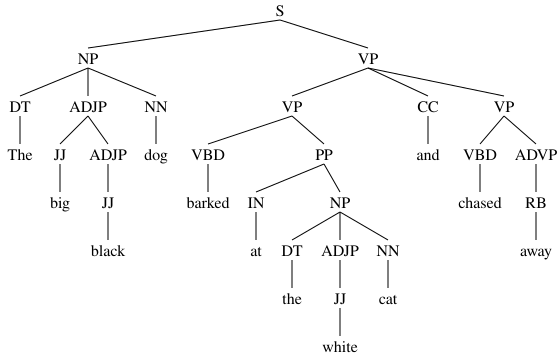


ASCII representation:
                               S                                       
      _________________________|____________                            
     |                                      VP                         
     |                              ________|___________________        
     |                             VP                |          |      
     |                    _________|___              |          |       
     NP                  |             PP            |          |      
  ___|______________     |      _______|____         |          |       
 |      ADJP        |    |     |            NP       |          VP     
 |    ___|_____     |    |     |    ________|____    |     _____|___    
 |   |        ADJP  |    |     |   |       ADJP  |   |    |        ADVP
 |   |         |    |    |     |   |        |    |   |    |         |   
 DT  JJ        JJ   NN  VBD    IN  DT       JJ   NN  CC  VBD        RB 
 |   |         |    |    |     |   

In [7]:
# Display each parse tree graphically using svgling
for i, tree in enumerate(trees, 1):
    print("--- Parse Tree", i, "---")
    print("String representation:", tree)
    print()
    # Graphical tree (rendered inline in Jupyter -- same style as sample)
    display(svgling.draw_tree(tree))
    print()
    # ASCII fallback
    print("ASCII representation:")
    tree.pretty_print()


Shallow Chunk Tree (NP/VP chunking):


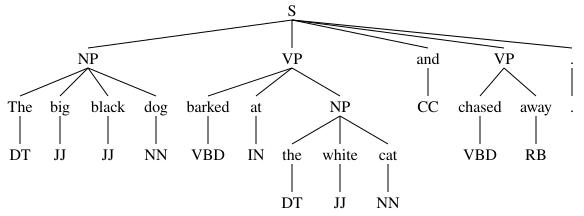


                                             S                                                         
   __________________________________________|_______________________________________________           
  |     |           |                                       VP                               |         
  |     |           |                         ______________|_______                         |          
  |     |           NP                       |        |             NP                       VP        
  |     |     ______|_______________         |        |      _______|_______          _______|_____     
and/CC ./. The/DT big/JJ black/JJ dog/NN barked/VBD at/IN the/DT white/JJ cat/NN chased/VBD     away/RB



In [8]:
# Shallow Chunk Tree (NP/VP) as additional syntactic view
chunk_grammar = r"""
    NP: {<DT><JJ>*<NN>}
    VP: {<VBD><IN>?<NP>?<RB>?}
"""
chunker    = nltk.RegexpParser(chunk_grammar)
chunk_tree = chunker.parse(nltk_tags)

print("Shallow Chunk Tree (NP/VP chunking):")
display(svgling.draw_tree(chunk_tree))
print()
chunk_tree.pretty_print()


### Parse Tree Structure Explanation

The sentence *"The big black dog barked at the white cat and chased away"* has the following hierarchical syntactic structure:

```
S (Sentence)
├── NP (Noun Phrase): "The big black dog"
│   ├── DT  : 'The'
│   ├── ADJP: 'big black'
│   │   ├── JJ: 'big'
│   │   └── JJ: 'black'
│   └── NN  : 'dog'
└── VP (Verb Phrase) [coordinated by 'and']
    ├── VP₁: "barked at the white cat"
    │   ├── VBD : 'barked'
    │   └── PP  : "at the white cat"
    │       ├── IN : 'at'
    │       └── NP : "the white cat"
    │           ├── DT : 'the'
    │           ├── JJ : 'white'
    │           └── NN : 'cat'
    ├── CC : 'and'
    └── VP₂: "chased away"
        ├── VBD : 'chased'
        └── ADVP: 'away'
            └── RB: 'away'
```

The coordinated VP structure (`VP → VP CC VP`) captures the fact that the subject *"the big black dog"* performs two actions joined by the conjunction *"and"*:
1. *barked at the white cat* (VBD + PP)
2. *chased away* (VBD + ADVP)